In [1]:
import copy
import numpy as np
import pandas as pd
# import uproot as ur
from scipy.stats import norm
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter, AutoMinorLocator, MultipleLocator, FuncFormatter

# setting random seed for reproducibility
np.random.seed(2150237)

In [2]:
# function to plot and count particles under the peak 
def particle_count( df, particle, key = 'fM', units = 'given units', steps = 200, bins = None, 
                    ax = None, title = None, par = None, peak_region = None) :

    p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"
    
     # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    if bins is None :
        max_x = X.max()
        min_x = X.min()
        bins  = np.linspace( min_x, max_x, steps  )
    hist, bin_edges = np.histogram( X, bins = bins )
    errors = np.sqrt( hist )
    errors = np.clip( errors, 1, None )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    bin_w = bin_edges[ 2 ] - bin_edges[ 1 ]

    def fit_function( x, A, mu, sigma, a, b, c ) :
        signal     = norm.pdf( x, loc = mu, scale = sigma )
        background = a * x**2 + b * x + c
        return A * signal + background

    # if not provided, using an ansatz to optimize the fit search
    if par is None :
        mu_0    = 1.86484 if particle == 'D0' else 2.28646 # PDG mass (GeV) 
        sigma_0 = 0.05 if particle == 'D0' else 0.02 # MC mass sigma (GeV)
        # using backgound interpolation as ansatz for the parabolic background
        # for the background we exclude the peak region, 
        # if not provided a 3 sigma region around the peak is used
        if peak_region is None :
            peak_region = ( mu_0 - 3.0 * sigma_0, mu_0 + 3.0 * sigma_0 )
        bg_mask = ( x_values < peak_region[0] ) | ( x_values > peak_region[1] )
        # fit background with a polynomial fit
        a_0, b_0, c_0 = np.polyfit( x = x_values[ bg_mask ], y = hist[ bg_mask ],
                                    w = 1.0 / errors[ bg_mask ], deg = 2 )
        # find the point corresponding to the expected center
        mu_bin = np.digitize( mu_0, bin_edges )
        mu_A = hist[ mu_bin ]
        mu_x = x_values[ mu_bin ]
        A_0 = np.abs( mu_A - ( c_0 + b_0 * mu_x + a_0 * mu_x**2 ) ) / norm.pdf( mu_x, loc = mu_0, scale = sigma_0 )
        par = [
                A_0,     # 0: A
                mu_0,    # 1: mu
                sigma_0, # 2: sigma
                a_0,     # 3: a
                b_0,     # 4: b
                c_0      # 5: c
                ]

    # setting parameter bounds to improve interpolation
    par_lb = [
                0.0,               # 0: A > 0
                x_values.min(),    # 1: mu in range
                1e-5,              # 2: sigma not expected to be lower than PDG precision
                -np.inf,           # 3: a no limit
                -np.inf,           # 4: b no limit
                0.0                # 5: c > 0 (costant bg should be positive)
                ]
    x_range = x_values.max() - x_values.min() 
    A_max = hist.max() * x_range
    par_ub = [
                A_max,             # 0: A < Fig area, seems reasonable
                x_values.max(),    # 1: mu in range
                x_range,           # 2: sigma not expected to be grater than the fig range
                np.inf,            # 3: a no limit
                np.inf,            # 4: b no limit
                hist.max() * 100   # 5: c < 100 * max y, seems reasonable
                ]
    try :
        fit_results = curve_fit(
                                f       = fit_function,
                                xdata   = x_values,
                                ydata   = hist,
                                sigma   = errors,
                                p0      = par,
                                bounds  = (par_lb, par_ub),
                                maxfev  = 500 )
    
        fit_par = fit_results[0]
        # mass_error = np.sqrt( fit_results[1][1, 1] )
        mass_error = np.sqrt( fit_results[0][2] / hist.shape[0] )
    except RuntimeError as e:
        print(f"Fit failed:\n{e}")
        print("Returning initial parameters")
        fit_par = np.array(par)
        mass_error = 0.0
    
    A_fit, mu_fit, sigma_fit, a_fit, b_fit, c_fit = fit_par
    # particle counting from the Gaussian
    p_counts = ( A_fit * ( norm.cdf( bins[-1], loc = mu_fit, scale = sigma_fit ) - norm.cdf( bins[0], loc = mu_fit, scale = sigma_fit ) ) ) / bin_w
    
    do_show = False
    if ax is None :
        do_show = True
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    # Plot fitted curve (Parabolic background model).
    ax.plot( x_values, fit_function( x_values, *fit_par), color='darkred', alpha = 0.75, linewidth=1.5, label='data fit with parabolic background')
    # Plotting the theoretical and interpolated value for the particle
    ax.axvline( x = mu_0, color = 'midnightblue', ls = '--', alpha = 0.65, label = f'theoretical {p_name} mass' )
    ax.axvline( x = mu_fit, color = 'darkred', ls = '--', alpha = 0.65, label = f'computed {p_name} mass' )
    # ax.set_xlim( min_x, max_x )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    if title is None :
        ax.set_title( f"{key} distribution for selected data" )
    else :
        ax.set_title( title )
    ax.set_xlabel( f"{key} [{units}]")
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")    
    ax.table( 
        cellText = [[f"{X.shape[0]}"], [f"{X[X < bin_edges[0] ].shape[0]}"], [f"{X[X > bin_edges[-1] ].shape[0]}"],
                    [f"{p_counts:.0f}"], [f"{mu_fit:.3f} {units}"], [f"{sigma_fit:.3f} {units}"] ],
        rowLabels = [ 'Entries', 'Underflow', 'Overflow', ( p_name + ' Count'), 'Mean', 'Std Dev'],
        bbox = [0.77, 0.75, 0.15, 0.22 ],
        edges = 'open',
        rowLoc = 'left',
        )
    ax.legend( loc = 'lower left')
    if do_show : plt.show()
    fit_par = np.append( fit_par, [p_counts, mass_error] )
    return fit_par

In [3]:
# 1.4) Divide into Pt regions, as decided a priori
DZ_fPt_Train_Ranges = [ (0, 2), (2, 3.2), (3.2, 5), (5, 16) ]
DZ_fPt_Extract_Ranges = [ [(0, 0.7), (0.7, 1), (1, 1.25), (1.25, 1.5), (1.5, 1.75), (1.75, 2)], [(2, 2.2), (2.2, 2.5), (2.5, 2.8), (2.8, 3.2)], [(3.2, 4), (4, 5)], [(5, 16)] ]
# DZ_fPt_Extract_Ranges = [ [ (1.5, 1.75), (1.75, 2)], [(2, 2.2), (2.2, 2.5), (2.5, 2.8), (2.8, 3.2)], [(3.2, 4), (4, 5)], [(5, 16)] ]
LC_fPt_Train_Ranges = [ (0, 3.1), (3.1, 4.8), (4.8, 20)]
# LC_fPt_Extract_Ranges = [ [(0, 2.2), (2.2, 2.35), (2.35, 2.5), (2.5, 2.7), (2.7, 2.9), (2.9, 3.1)], [(3.1, 3.3), (3.3, 3.5), (3.5, 3.8), (3.8, 4.2), (4.2, 4.8)], [(4.8, 20)]]
LC_fPt_Extract_Ranges = [ [(0, 2.2), (2.2, 2.35), (2.35, 2.5), (2.5, 2.7), (2.7, 2.9), (2.9, 3.1)], [(3.1, 3.3), (3.3, 3.5), (3.5, 3.8), (3.8, 4.2), (4.2, 4.8)], [(4.8, 20)]]

# also the mass interval filter can be used, based on MC
# DZ_fM_cut = [ (1.66, 2.07), (1.66, 2.07), (1.66, 2.07), (1.66, 2.07) ]
DZ_fM_cut = [ (1.67, 2.06), (1.67, 2.06), (1.67, 2.06), (1.67, 2.06) ]
# LC_fM_cut = [ (2.0, 2.5), (1.9, 2.68), (1.9, 2.7) ]
LC_fM_cut = [ (2.1, 2.55), (2.1, 2.55), (2.0, 2.6) ]

# cut for what we can use as BG, based on the MC graphs (these are the peaks)
DZ_fM_peak = [ (1.815, 1.915), (1.805, 1.925), (1.805, 1.935), (1.795, 1.945) ]
LC_fM_peak = [ (2.26, 2.31), (2.26, 2.31), (2.26, 2.31) ]

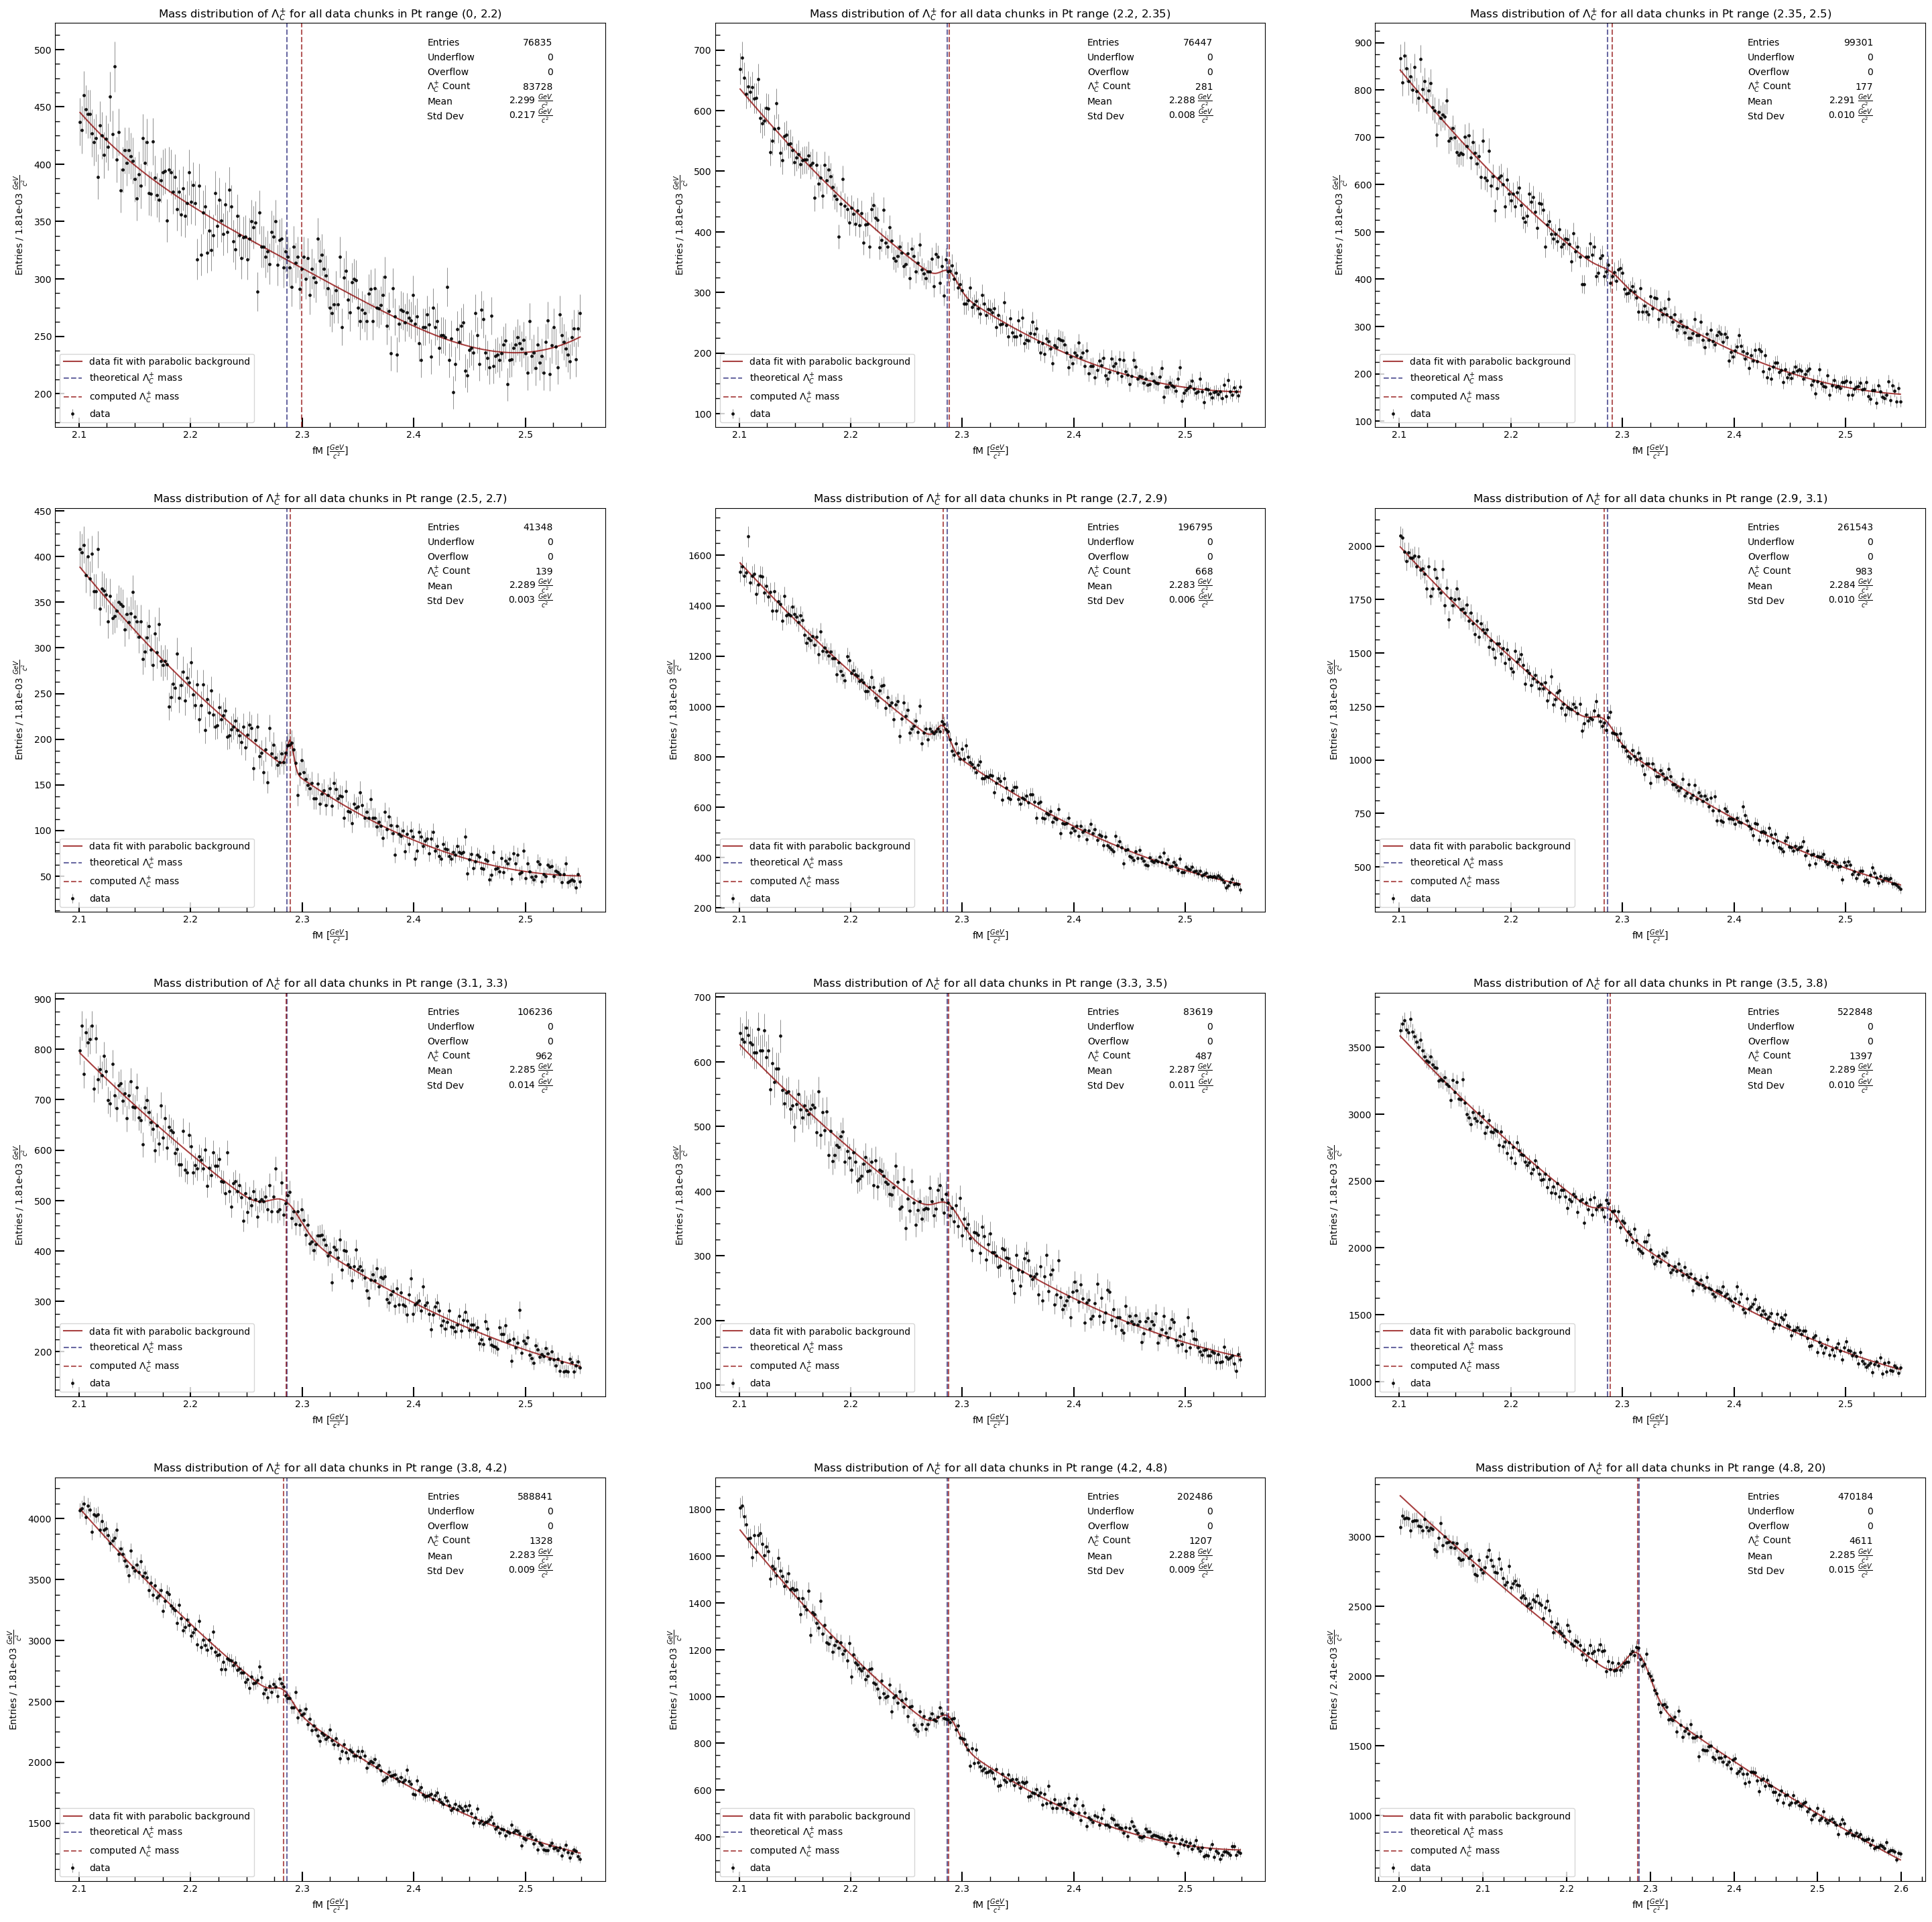

In [4]:

# particle  = 'D0'
particle  = 'LC'

p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"
pt_range = DZ_fPt_Train_Ranges if particle == 'D0' else LC_fPt_Train_Ranges
sub_pt_range = DZ_fPt_Extract_Ranges if particle == 'D0' else LC_fPt_Extract_Ranges
M_cut = DZ_fM_cut if particle == 'D0' else LC_fM_cut
peak_cut = DZ_fM_peak if particle == 'D0' else LC_fM_peak

# cut_index = 0
# cut_subindex = 0
# pt_int = sub_pt_range[ cut_index ][ cut_subindex ]

# making all fit into a single plot
figures = sum( [ len( main_cut ) for main_cut in sub_pt_range ] )
cols = 3
rows = figures // cols + ( ( figures % cols ) > 0 )
i = 0
# this always gives a 2d array for axs
fig, axs = plt.subplots( nrows = rows, ncols = cols, figsize=( 12*cols, 9*rows ), squeeze = False )

results = { 'Pt' : [], 'Particles' : [], 'Mass' : [], 'Sigma' : [], 'Pull' : [], 'Efficiency' : [], 'Beauty Efficiency' : [] }

for cut_index, main_cut in enumerate( sub_pt_range ) :
    property_file = f"./selected_df/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv"
    property_df = pd.read_csv( property_file )
    
    for cut_subindex, pt_int in enumerate( main_cut ) :

        # output_file = f"/mnt/CandidateReducedDF/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"
        output_file = f"./selected_df/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"   
        
        n_bin = 250
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], n_bin ) # bin edges
        # histo = np.zeros( ( len( train_lab ), ( n_bin - 1 ) ) )
        
        # print( f"Pt interval used: {pt_int}")
        # all data plot
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], 250 ) # bin edges
        
        data = pd.read_csv( output_file )

        n_col = i % cols
        n_row = i // cols
        ax = axs[ n_row ][ n_col ]

        fit_par = particle_count( data, particle, key = 'fM', units = r'$\frac{GeV}{c^2}$', ax = ax, peak_region = peak_cut[cut_index],
                    bins = bins, title = f"Mass distribution of {p_name} for all data chunks in Pt range {pt_int}" )
        
        results[ 'Pt' ].append( copy.deepcopy( pt_int ) )
        results[ 'Particles' ].append( copy.deepcopy( np.round( fit_par[6] ) ) )
        results[ 'Mass' ].append( copy.deepcopy( np.round( fit_par[1], decimals = 3 ) ) )
        results[ 'Sigma' ].append( copy.deepcopy( np.round( fit_par[2], decimals = 3 ) ) )
        
        mu_0    = 1.86484 if particle == 'D0' else 2.28646 # PDG mass (GeV) 
        sigma_0 = 0.00005 if particle == 'D0' else 0.00014 # PDG mass sigma (GeV)

        # adding the pull, the distance between theoretical and experimental mass in sigma units
        results[ 'Pull' ].append( np.round( np.abs( fit_par[1] - mu_0 ) / np.hypot( fit_par[7], sigma_0 ) , decimals = 2 ) )
        # adding efficiency computed on MC for compacting dataframe
        results[ 'Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Beauty Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Beauty Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        
        i += 1
        
        del data

results_df = pd.DataFrame( results )
plt.show()

In [5]:
output_file = f"./selected_df/Particle_{particle}_Counts.csv"
results_df.to_csv( output_file, mode = 'w', header = True )
results_df

,Pt,Particles,Mass,Sigma,Pull,Efficiency,Beauty Efficiency
0,"(0, 2.2)",83728.0,2.299,0.217,0.43,0.0026,0.0011
1,"(2.2, 2.35)",281.0,2.288,0.008,0.37,0.0068,0.0042
2,"(2.35, 2.5)",177.0,2.291,0.010,0.67,0.0084,0.0051
3,"(2.5, 2.7)",139.0,2.289,0.003,0.82,0.0056,0.0027
4,"(2.7, 2.9)",668.0,2.283,0.006,0.73,0.0135,0.0070
5,"(2.9, 3.1)",983.0,2.284,0.010,0.46,0.0179,0.0095
6,"(3.1, 3.3)",962.0,2.285,0.014,0.14,0.0183,0.0095
7,"(3.3, 3.5)",487.0,2.287,0.011,0.15,0.0158,0.0060
8,"(3.5, 3.8)",1397.0,2.289,0.010,0.44,0.0427,0.0242
9,"(3.8, 4.2)",1328.0,2.283,0.009,0.52,0.0499,0.0197


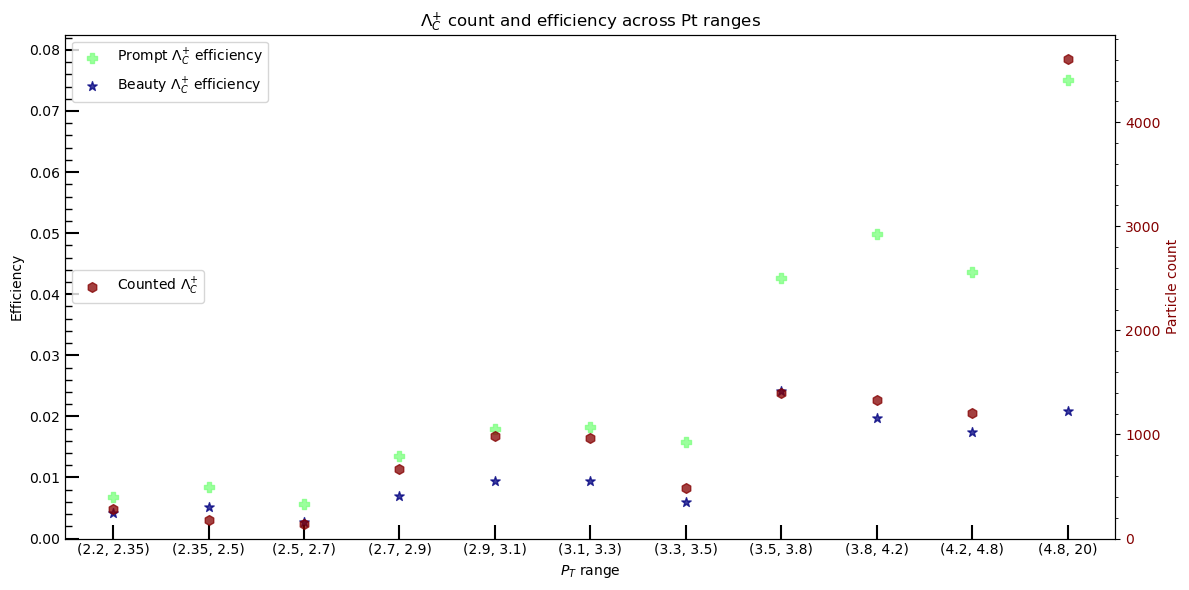

In [6]:
# Plotting obtained particles and efficiencies for different Pt ranges
# excluding low pt region in which we were not able to get results
pt_treshold = 1

# retrieving the data
pt_intervals = results_df[ 'Pt' ].iloc[ pt_treshold : ].to_numpy()
particles_ct = results_df[ 'Particles' ].iloc[ pt_treshold : ].to_numpy()
efficiency   = results_df[ 'Efficiency' ].iloc[ pt_treshold : ].to_numpy()
b_efficiency = results_df[ 'Beauty Efficiency' ].iloc[ pt_treshold : ].to_numpy()

N = 3
x = np.arange( pt_intervals.shape[0] )
# define color and marker palette
colors  = plt.get_cmap( 'jet' )( np.arange( 3 ) / ( N - 0.99 ) )
markers = [ "*", "P", "h", "s", "d", "p", "8", "D", "v", "^", "<", ">" ]

fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 12, 6 ) )

ax.scatter( x = x, y = efficiency,   marker = markers[1], color = colors[1],
            label = f'Prompt {p_name} efficiency', alpha = 0.75, s = 50 )
ax.scatter( x = x, y = b_efficiency, marker = markers[0], color = colors[0],
            label = f'Beauty {p_name} efficiency', alpha = 0.75, s = 50 )
ax.set_ylim( 0.0, efficiency.max()*1.1 )
ax.xaxis.set_major_locator(MultipleLocator( 1 ))
ax.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
ax.set_xticks( x, labels = pt_intervals )
ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
ax.set_title( f"{p_name} count and efficiency across Pt ranges")
ax.set_xlabel( r"$P_T$ range")
ax.set_ylabel( "Efficiency", color='black')
ay = ax.twinx()        
ay.scatter( x = x, y = particles_ct, marker = markers[2], color = colors[2],
            label = f'Counted {p_name}', alpha = 0.75, s = 50 )
ay.set_ylabel( 'Particle count', color = colors[2] )
ay.set_ylim( 0, int( particles_ct.max()*1.05 ) )
ay.tick_params( axis='y', labelcolor=colors[ 2 ] )
ay.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
ax.legend( loc = 'upper left')
ay.legend( loc = 'center left')
fig.tight_layout()  
plt.show()